# Text Summarization using LangChain

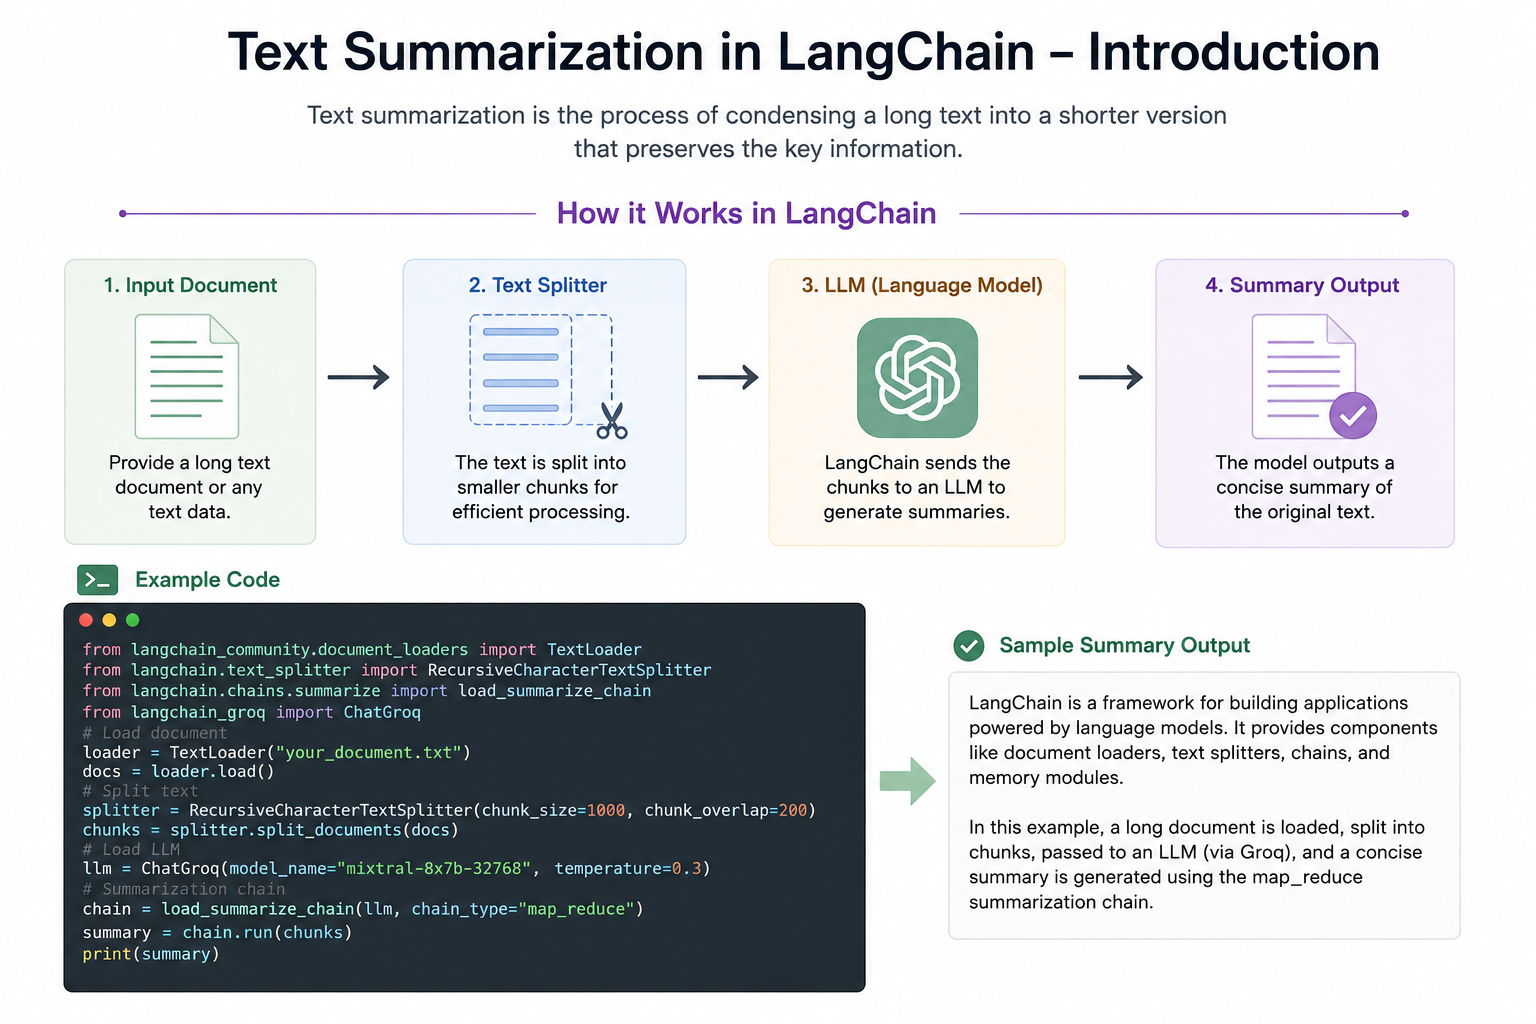

https://reference.langchain.com/python/langchain/agents/middleware/summarization

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
from langchain_groq import ChatGroq
api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=api_key, model = "llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013F5E51CF10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013F5E51F110>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

In [5]:
speech = """
It is an honour to speak to you today about a vision that can transform our lives and our nation. When we think of building a strong future, we must look at the incredible power hidden within the youth. As Dr. A.P.J. Abdul Kalam beautifully said, "Dream, dream, dream. Dreams transform into thoughts and thoughts result in action."Dreams are not what you see in your sleep; they are the things that do not let you sleep. To achieve greatness, every individual must build their life on four essential pillars.The first pillar is having a great aim. Small aim is a crime; you must have a great global vision. Do not fear big challenges. Set your sights high, because when you aim for the stars, you break the chains of mediocrity.The second pillar is continuously acquiring knowledge. Knowledge is a unique tool. It gives you creativity, creativity leads to thinking, thinking provides knowledge, and knowledge makes you great. Never stop being a student of life. Read books, observe the world, and learn from every person you meet.The third pillar is hard work. No great achievement is born out of comfort. Dr. Kalam often reminded us that if you want to shine like a sun, you must first burn like a sun. Sweat, dedication, and relentless effort are the only keys to unlocking your true potential.The fourth and final pillar is perseverance and managing failure. Life is a journey filled with obstacles. You will face defeats, but defeat should not defeat you. You must become the captain of your problems, defeat the difficulties, and succeed. True leaders take responsibility for failures and share the rewards of success with their teams.India is a land of a billion people, and our greatest strength is our youth. If a billion people ignite their minds, no power on earth can stop our progress. We must work together to create a prosperous, healthy, and secure nation. We must move from asking "What can the country do for me?" to asking "What can I do for my country?"Let us leave this room today with a promise to ourselves. Let us vow to fly with the wings of fire, to work with integrity, and to never give up on our righteous paths. Together, we can take our nation to the pinnacle of success.Thank you, and Jai Hind!
 """

In [11]:
chat_message = [
    SystemMessage(content = "You are expert in summarizing the speech"),
    HumanMessage(content=f"Please provide a short and concise summary of the follow speech:\n Text: {speech}")

]


In [12]:
llm.get_num_tokens(speech)

478

In [17]:
llm.invoke(chat_message)

AIMessage(content="Here is a concise summary of the speech:\n\nThe speaker emphasizes the importance of harnessing the power of youth to transform the nation. To achieve greatness, individuals must build their lives on four pillars: a great aim, continuous knowledge acquisition, hard work, and perseverance despite failure. By working together and focusing on what they can contribute to their country, India's youth can unlock their true potential and lead the nation to success. The speaker concludes by urging the audience to make a promise to themselves to work with integrity, never give up, and strive for greatness, ultimately taking the nation to the pinnacle of success.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 526, 'total_tokens': 648, 'completion_time': 0.202756296, 'completion_tokens_details': None, 'prompt_time': 0.030627486, 'prompt_tokens_details': None, 'queue_time': 0.060762843, 'total_time': 0.233383782}, 'model_nam

In [18]:
llm.invoke(chat_message).content

"Here's a concise summary of the speech:\n\nThe speaker emphasizes the importance of youth in building a strong future for the nation. To achieve greatness, individuals must build their lives on four essential pillars: 1) setting a high aim, 2) continuously acquiring knowledge, 3) working hard, and 4) persevering through failure. The speaker calls on the youth to take responsibility for their progress and work together to create a prosperous, healthy, and secure nation. Ultimately, the goal is to move from a self-centered mindset to a nation-centered mindset, where individuals strive to contribute to the country's success."

## Prompt Template Text Summarization

In [19]:
from langchain_classic.chains import LLMChain
from langchain_core.prompts import PromptTemplate
generictemplate = """
Write a summary of the following speech:
Speech:{speech}
Translate the precise summary to {language}

"""

prompt = PromptTemplate(
    input_variables=['speech', 'language'],
    template = generictemplate
)

prompt


PromptTemplate(input_variables=['language', 'speech'], input_types={}, partial_variables={}, template='\nWrite a summary of the following speech:\nSpeech:{speech}\nTranslate the precise summary to {language}\n\n')

In [22]:
complete_prompt = prompt.format(speech=speech, language = "French")

In [23]:
complete_prompt

'\nWrite a summary of the following speech:\nSpeech:\nIt is an honour to speak to you today about a vision that can transform our lives and our nation. When we think of building a strong future, we must look at the incredible power hidden within the youth. As Dr. A.P.J. Abdul Kalam beautifully said, "Dream, dream, dream. Dreams transform into thoughts and thoughts result in action."Dreams are not what you see in your sleep; they are the things that do not let you sleep. To achieve greatness, every individual must build their life on four essential pillars.The first pillar is having a great aim. Small aim is a crime; you must have a great global vision. Do not fear big challenges. Set your sights high, because when you aim for the stars, you break the chains of mediocrity.The second pillar is continuously acquiring knowledge. Knowledge is a unique tool. It gives you creativity, creativity leads to thinking, thinking provides knowledge, and knowledge makes you great. Never stop being a s

In [24]:
llm.get_num_tokens(complete_prompt)

500

In [25]:
llm_chain = LLMChain(llm = llm, prompt = prompt)
summary = llm_chain.invoke({'speech':speech, 'language':'Hindi'})
summary

C:\Users\Uditya\AppData\Local\Temp\ipykernel_12904\2192414600.py:1: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 2.0.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  llm_chain = LLMChain(llm = llm, prompt = prompt)


{'speech': '\nIt is an honour to speak to you today about a vision that can transform our lives and our nation. When we think of building a strong future, we must look at the incredible power hidden within the youth. As Dr. A.P.J. Abdul Kalam beautifully said, "Dream, dream, dream. Dreams transform into thoughts and thoughts result in action."Dreams are not what you see in your sleep; they are the things that do not let you sleep. To achieve greatness, every individual must build their life on four essential pillars.The first pillar is having a great aim. Small aim is a crime; you must have a great global vision. Do not fear big challenges. Set your sights high, because when you aim for the stars, you break the chains of mediocrity.The second pillar is continuously acquiring knowledge. Knowledge is a unique tool. It gives you creativity, creativity leads to thinking, thinking provides knowledge, and knowledge makes you great. Never stop being a student of life. Read books, observe the 